# Model Evaluation and Error Analysis

**Objective:** Evaluate the generalization performance of the tuned Random Forest pipeline.
This notebook investigates global residual diagnostics and segmented error metrics to determine 
model readiness for production and identify necessary business guardrails.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Set visualization style for professional reporting
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (16, 5), 'figure.dpi': 100})

## 1. Data & Model Ingestion
Load the holdout test set and the finalized modeling pipeline.

In [2]:
# Define paths
DATA_PATH = "../data/processed/"
MODEL_PATH = "../models/"

# Load test features and target
X_test = pd.read_csv(f"{DATA_PATH}X_test.csv")
y_test = pd.read_csv(f"{DATA_PATH}y_test.csv")

# Load the trained Random Forest Pipeline
model = joblib.load(f"{MODEL_PATH}rf_tuned_pipeline.joblib")

# Verify shapes
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (2731, 6)
y_test shape: (2731, 1)


## 2. Global Residual Diagnostics
Generate predictions in log-space, inverse-transform to standard currency (INR), 
and calculate residuals.

In [3]:
# 1. Generate predictions in log-space
y_pred_log = model.predict(X_test)

# 2. Inverse-transform to Rupees (INR) using expm1 (inverse of log1p)
# Note: y_test is a DataFrame, we need to extract the series/array
y_test_inr = np.expm1(y_test['AskPrice_Log'].values)
y_pred_inr = np.expm1(y_pred_log)

# 3. Calculate Global Metrics
mae = mean_absolute_error(y_test_inr, y_pred_inr)
rmse = np.sqrt(mean_squared_error(y_test_inr, y_pred_inr))
r2 = r2_score(y_test_inr, y_pred_inr)

print(f"Global Test MAE:  ₹{mae:,.2f}")
print(f"Global Test RMSE: ₹{rmse:,.2f}")
print(f"Global Test R2:   {r2:.4f}")

# 4. Calculate Residuals (Actual - Predicted)
# Positive residual = Underprediction; Negative residual = Overprediction
residuals = y_test_inr - y_pred_inr

Global Test MAE:  ₹309,522.26
Global Test RMSE: ₹1,169,144.81
Global Test R2:   0.5413



### 2.1 Diagnostic Plots
Visualizing the distribution and behavior of the residuals across the price spectrum.

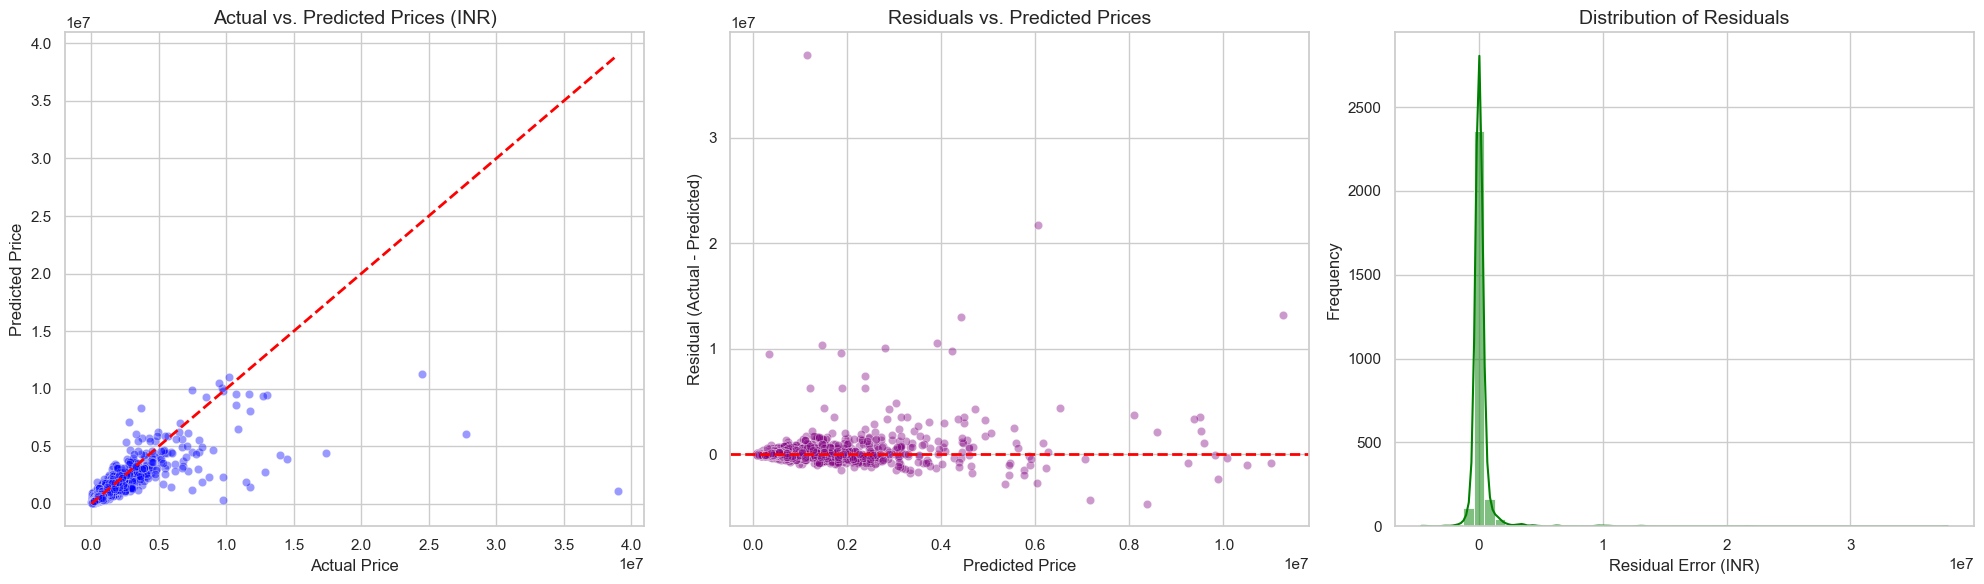

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Actual vs. Predicted
sns.scatterplot(x=y_test_inr, y=y_pred_inr, alpha=0.4, ax=axes[0], color='blue')
# Draw the ideal 1:1 line
min_val = min(y_test_inr.min(), y_pred_inr.min())
max_val = max(y_test_inr.max(), y_pred_inr.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_title('Actual vs. Predicted Prices (INR)', fontsize=14)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# Plot 2: Residuals vs. Predicted
sns.scatterplot(x=y_pred_inr, y=residuals, alpha=0.4, ax=axes[1], color='purple')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs. Predicted Prices', fontsize=14)
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')

# Plot 3: Residual Distribution
sns.histplot(residuals, bins=50, kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribution of Residuals', fontsize=14)
axes[2].set_xlabel('Residual Error (INR)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Segmented Error Analysis
To understand where the model fails, we segment the errors by actual price brackets.
We will calculate MAE and MAPE (Mean Absolute Percentage Error) for each bracket.

--- Error Metrics by Price Bracket ---


,Price_Bracket,Count,MAE_Formatted,MAPE_Formatted
0,1. Budget (< 5L),1212,"₹92,687",37.02%
1,2. Mid-Range (5L - 15L),1089,"₹196,315",23.26%
2,3. Premium (15L - 30L),274,"₹507,520",24.56%
3,4. Luxury (> 30L),156,"₹2,436,668",33.71%


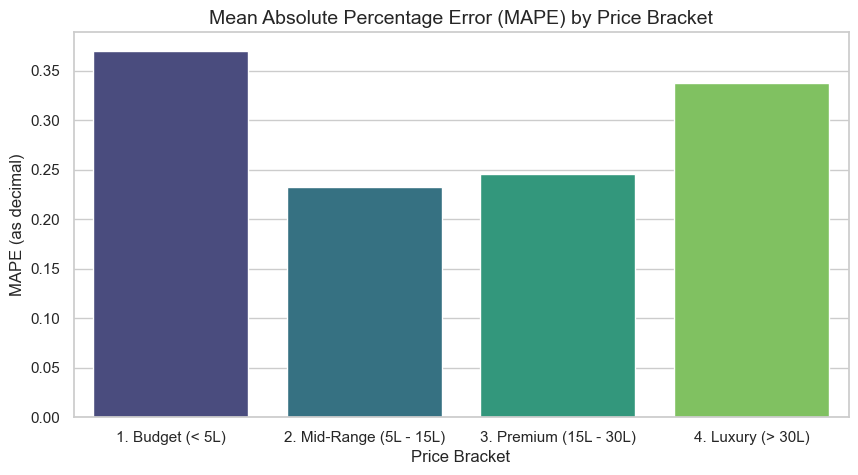

In [11]:
# 1. Create a DataFrame for analysis
analysis_df = pd.DataFrame({
    'Actual_INR': y_test_inr,
    'Predicted_INR': y_pred_inr,
    'Residual': residuals,
    'Absolute_Error': np.abs(residuals)
})

# 2. Calculate Absolute Percentage Error per row
# (Avoid division by zero just in case, though price should never be 0)
analysis_df['APE'] = analysis_df['Absolute_Error'] / analysis_df['Actual_INR']

# 3. Define Price Brackets (Bins in INR)
bins = [0, 500000, 1500000, 3000000, np.inf]
labels = ['1. Budget (< 5L)', '2. Mid-Range (5L - 15L)', '3. Premium (15L - 30L)', '4. Luxury (> 30L)']

# Categorize each row into a bracket based on the ACTUAL price
analysis_df['Price_Bracket'] = pd.cut(analysis_df['Actual_INR'], bins=bins, labels=labels)

# 4. Group by bracket and calculate metrics
segment_metrics = analysis_df.groupby('Price_Bracket').agg(
    Count=('Actual_INR', 'size'),
    MAE=('Absolute_Error', 'mean'),
    MAPE=('APE', 'mean')
).reset_index()

# 5. Format for professional reporting
segment_metrics['MAE_Formatted'] = segment_metrics['MAE'].apply(lambda x: f"₹{x:,.0f}")
segment_metrics['MAPE_Formatted'] = segment_metrics['MAPE'].apply(lambda x: f"{x * 100:.2f}%")

print("--- Error Metrics by Price Bracket ---")
display(segment_metrics[['Price_Bracket', 'Count', 'MAE_Formatted', 'MAPE_Formatted']])

# 6. Optional: Visualize MAPE by Bracket
plt.figure(figsize=(10, 5))
sns.barplot(x='Price_Bracket', y='MAPE', data=segment_metrics, palette='viridis')
plt.title('Mean Absolute Percentage Error (MAPE) by Price Bracket', fontsize=14)
plt.ylabel('MAPE (as decimal)')
plt.xlabel('Price Bracket')
plt.show()